# Experiment 1: Temperature as an Input Feature

Companion notebook to [`README.md`](README.md) for the DAAN 570 course project (Temperature Prediction with Deep Learning).

**Hypothesis**: `temperature_2m` is the prediction target, but its own recent history is also a strong autoregressive signal. Does including the past `WINDOW_SIZE` hours of temperature alongside the existing weather covariates improve test MAE/RMSE over the baseline (weather-only) Transformer?

**What changed vs. the baseline** (`src/models/transformer/transformer_encoder_experiment.ipynb`): nothing except the input features -- see [`config.py`](config.py). Architecture, hyperparameters, data splits, and training loop are all shared with the baseline via `src/models/transformer/architecture.py` and `src/models/transformer/training.py`.

This notebook can run either locally (if `data/splits/` is already on your machine) or on Google Colab with a GPU runtime. The first code cell below handles both cases automatically.

## Setup

**Running on Colab**: this cell clones the (private) repo, installs dependencies, and pulls the Git-LFS-tracked raw data. One-time setup: create a fine-grained, read-only GitHub PAT for this repo and store it in Colab's Secrets manager (key icon in the left sidebar) under the name `GITHUB_PAT`, then grant this notebook access to it when prompted. Also select **Runtime > Change runtime type > GPU** before running.

**Running locally**: this cell detects that it's not on Colab and does nothing -- it assumes you already have the repo cloned, dependencies installed (`pip install -r requirements.txt`), and `data/splits/` available (or `data/raw/` present, from which splits regenerate automatically).

In [1]:
import shutil
import subprocess
import sys
from pathlib import Path

BRANCH = "exp01_temperature_feature"


def run(cmd):
    result = subprocess.run(cmd, shell=True)
    if result.returncode != 0:
        raise RuntimeError(f"Command failed (exit {result.returncode}): {cmd}")


try:
    import google.colab
    from google.colab import userdata

    REPO_DIR = Path("/content/repo")
    token = userdata.get("GITHUB_PAT")
    repo_url = f"https://{token}@github.com/LarryGreen-alt/Temperature_Prediction_DeepLearning.git"

    # A directory can be left behind by a previous failed attempt without
    # being a real git checkout -- only trust it if .git is actually there.
    if REPO_DIR.exists() and not (REPO_DIR / ".git").is_dir():
        shutil.rmtree(REPO_DIR)

    if (REPO_DIR / ".git").is_dir():
        run(f"git -C {REPO_DIR} fetch -q origin {BRANCH}")
        run(f"git -C {REPO_DIR} checkout -q {BRANCH}")
        run(f"git -C {REPO_DIR} pull -q origin {BRANCH}")
    else:
        run(f"git clone -q -b {BRANCH} {repo_url} {REPO_DIR}")

    get_ipython().run_line_magic("cd", str(REPO_DIR))
    run("pip install -q -r requirements.txt")
    run("apt-get -qq install -y git-lfs")
    # --force: the git-lfs apt package's post-install step already sets up
    # this same hook globally, so a plain `install` refuses as a safety
    # check against clobbering a *different*, unrelated pre-push hook.
    run("git lfs install --force")
    run("git lfs pull")

    PROJECT_ROOT = REPO_DIR
except ImportError:

    def find_project_root(marker="weather_main.py"):
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
            if (candidate / marker).exists():
                return candidate
        raise FileNotFoundError(f"Could not find project root (looking for {marker})")

    PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

/content/repo


In [2]:
import pandas as pd

from src.models.common import data
from src.models.common.compare import find_cached_experiment, compare
from src.models.common.plotting import plot_loss_curve, plot_mae_curve, plot_prediction_curve
from src.models.transformer.training import run_training, load_cached_results, timestamp_now
from src.models.transformer.experiments.exp01_temperature_feature.config import (
    CONFIG, EXPERIMENT_NAME, FEATURE_COLUMNS
)

## Data

Same source as the baseline: `data/splits/{train,dev,test}.csv`, derived from `data/raw/*.csv` via `src/data/preprocess.py` -> `src/data/split_dataset.py` (chronological 70/15/15 split per city). `data.load_splits()` regenerates `data/splits/` automatically if missing.

In [3]:
train_df, dev_df, test_df = data.load_splits()

print("Train rows:", len(train_df))
print("Dev rows  :", len(dev_df))
print("Test rows :", len(test_df))
train_df.head()

/content/repo/data/splits not found -- regenerating from /content/repo/data/raw (preprocess + split, ~20s)...
Processing data/raw/phoenix.csv
Processing data/raw/random.csv
Processing data/raw/denver.csv
Processing data/raw/atlanta.csv
Processing data/raw/boston.csv
Processing data/raw/los_angeles.csv
Processing data/raw/seattle.csv
Processing data/raw/fort_worth.csv
Processing data/raw/chicago.csv
Processing data/raw/dallas.csv
Processing data/raw/new_york.csv
Processing data/raw/san_antonio.csv
Processing data/raw/las_vegas.csv
Processing data/raw/austin.csv
Processing data/raw/miami.csv
Processing data/raw/houston.csv
--------------------------------
Finished preprocessing.
Rows: 1,612,800
Saved to: data/processed/features.csv
-------------------------------------
Dataset successfully split.
-------------------------------------
Training rows:   1,128,960
Development rows:241,920
Testing rows:    241,920
-------------------------------------
Saved to:
data/splits/train.csv
data/spli

,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,cloud_cover,precipitation,is_day,city,year,month,day,hour,day_of_week,day_of_year,hour_sin,hour_cos,day_sin,day_cos
0,2015-01-01 00:00:00,5.5,67.0,988.900024,7.4,1.0,0.0,0.0,atlanta.csv,2015,1,1,0,3,1,0.000000,1.000000,0.017213,0.999852
1,2015-01-01 01:00:00,4.4,66.0,988.900024,7.3,0.0,0.0,0.0,atlanta.csv,2015,1,1,1,3,1,0.258819,0.965926,0.017213,0.999852
2,2015-01-01 02:00:00,3.5,66.0,988.700012,6.0,53.0,0.0,0.0,atlanta.csv,2015,1,1,2,3,1,0.500000,0.866025,0.017213,0.999852
3,2015-01-01 03:00:00,2.7,66.0,989.000000,6.0,38.0,0.0,0.0,atlanta.csv,2015,1,1,3,3,1,0.707107,0.707107,0.017213,0.999852
4,2015-01-01 04:00:00,2.0,67.0,988.700012,6.6,30.0,0.0,0.0,atlanta.csv,2015,1,1,4,3,1,0.866025,0.500000,0.017213,0.999852


## Configuration

Hyperparameters (`CONFIG`) are identical to the baseline Transformer run -- the only difference from baseline is `FEATURE_COLUMNS`, which adds `temperature_2m` to the baseline's weather covariates.

In [4]:
print(CONFIG)
print()
print("Feature columns:", FEATURE_COLUMNS)
print("Baseline had:   ", data.FEATURE_COLUMNS)

TransformerConfig(window_size=24, forecast_horizon=3, d_model=64, num_heads=4, num_encoder_layers=2, ff_dim=128, dropout_rate=0.2, batch_size=32, epochs=25)

Feature columns: ['relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'cloud_cover', 'precipitation', 'is_day', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'temperature_2m']
Baseline had:    ['relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'cloud_cover', 'precipitation', 'is_day', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


## Train or load

Same caching behavior as the baseline notebook: this experiment's runs live under their own `models/Transformer/exp01_temperature_feature/` directory (separate from baseline), so an exact `CONFIG` match here only ever compares against other exp01 runs. Set `FORCE_RETRAIN = True` to bypass the cache and retrain regardless.

No cached experiment matches this config (or FORCE_RETRAIN=True) -- training now...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_sequence    │ (None, 24, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 11)    │         23 │ weather_sequence… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 64)    │        768 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 64)    │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 64)    │          0 │ dense_4[0][0]   

 Total params: 70,360 (274.85 KB)

 Trainable params: 70,337 (274.75 KB)

 Non-trainable params: 23 (96.00 B)

Epoch 1/25
35280/35280 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.5146 - mae: 1.4975 - rmse: 2.1836
Epoch 1: val_loss improved from None to 8.83464, saving model to /content/repo/models/Transformer/exp01_temperature_feature/checkpoints/best.keras

Epoch 1: finished saving model to /content/repo/models/Transformer/exp01_temperature_feature/checkpoints/best.keras
35280/35280 ━━━━━━━━━━━━━━━━━━━━ 229s 6ms/step - loss: 2.8949 - mae: 1.1861 - rmse: 1.7014 - val_loss: 8.8346 - val_mae: 2.4888 - val_rmse: 2.9723
Epoch 2/25
35274/35280 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9610 - mae: 1.0183 - rmse: 1.4003
Epoch 2: val_loss improved from 8.83464 to 7.74834, saving model to /content/repo/models/Transformer/exp01_temperature_feature/checkpoints/best.keras

Epoch 2: finished saving model to /content/repo/models/Transformer/exp01_temperature_feature/checkpoints/best.keras
35280/35280 ━━━━━━━━━━━━━━━━━━━━ 197s 6ms/step - loss: 1.9310 - mae: 1.0086 - rmse: 1.3896 - val_loss: 7.7483 - val_mae: 2

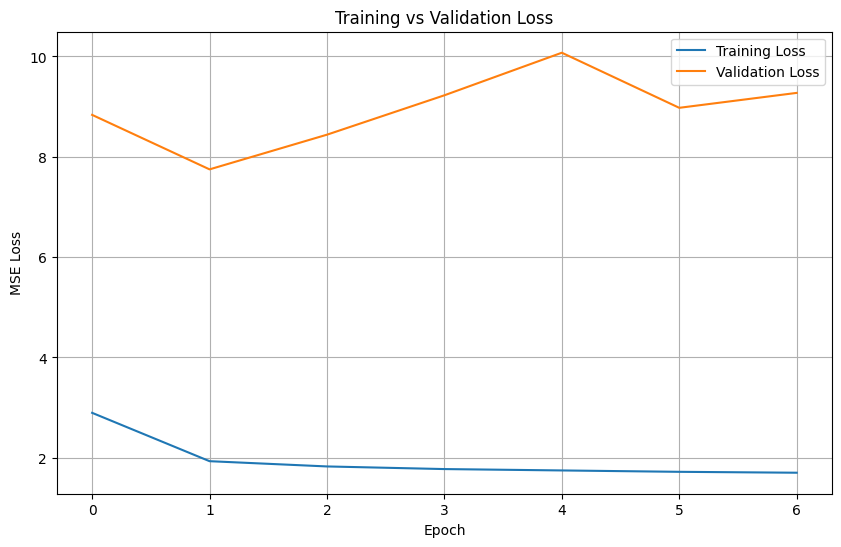

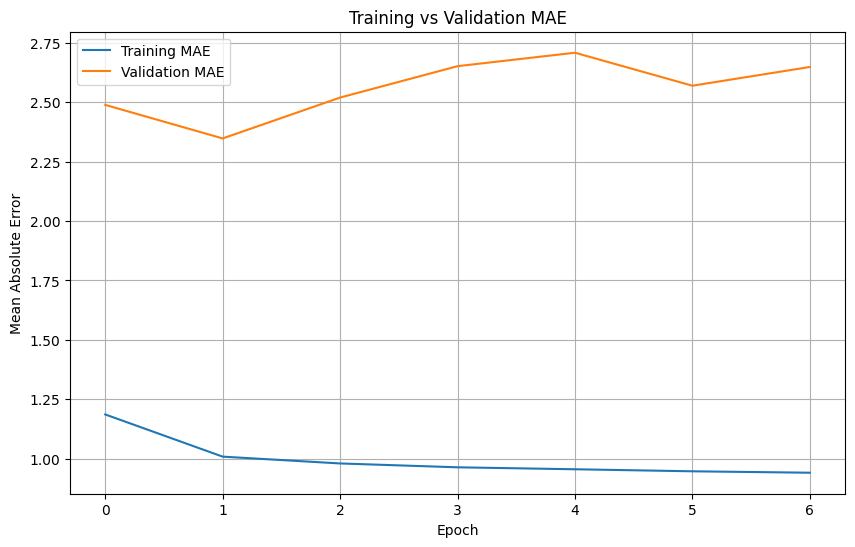

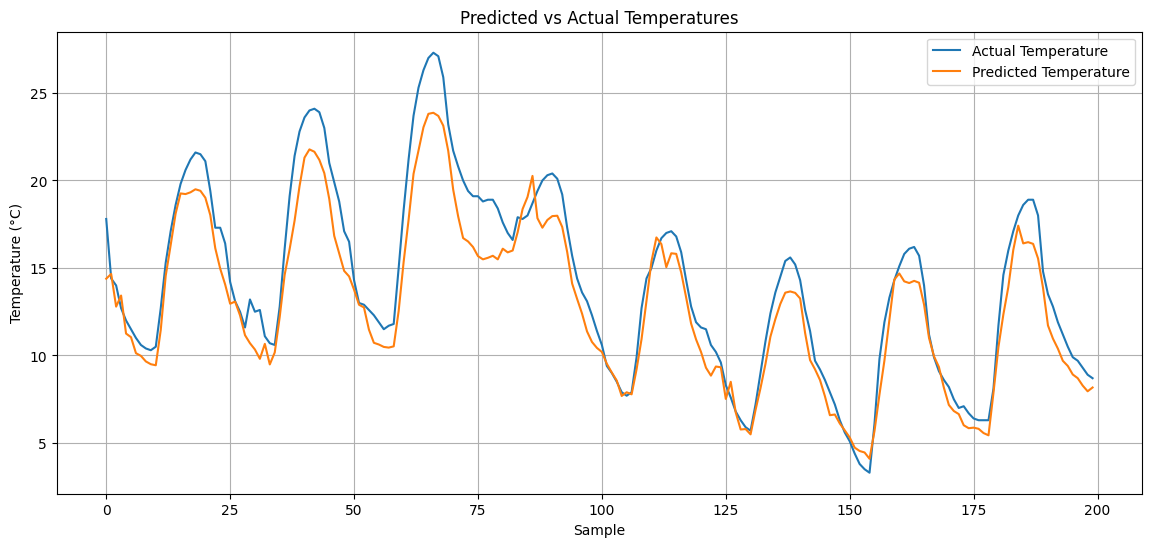

Experiment dir: /content/repo/models/Transformer/exp01_temperature_feature/experiments/2026-07-25_16-57-47


In [5]:
FORCE_RETRAIN = False

MODEL_ROOT = data.PROJECT_ROOT / "models" / "Transformer" / EXPERIMENT_NAME
checkpoint_path = MODEL_ROOT / "checkpoints" / "best.keras"

config_dict = CONFIG.to_dict()
cached_dir = None if FORCE_RETRAIN else find_cached_experiment(f"Transformer/{EXPERIMENT_NAME}", config_dict)

if cached_dir:
    print(f"Found a cached experiment matching this config: {cached_dir.name}")
    results = load_cached_results(cached_dir)
else:
    print("No cached experiment matches this config (or FORCE_RETRAIN=True) -- training now...")
    experiment_dir = MODEL_ROOT / "experiments" / timestamp_now()
    results = run_training(
        CONFIG, experiment_dir, checkpoint_path,
        feature_columns=FEATURE_COLUMNS, show_plots=True
    )

print("Experiment dir:", results["experiment_dir"])

## Results

Test Loss : 7.1103
Test MAE  : 2.2531
Test RMSE : 2.6665
Epochs trained: 7


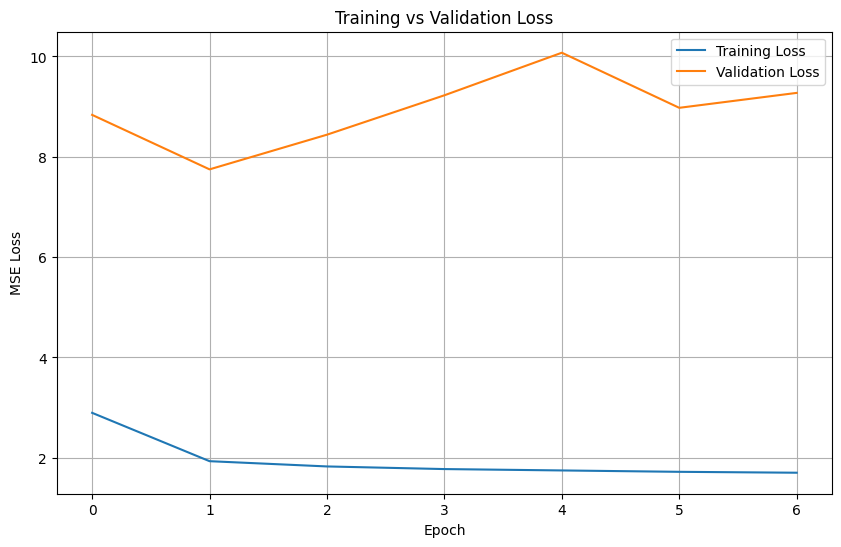

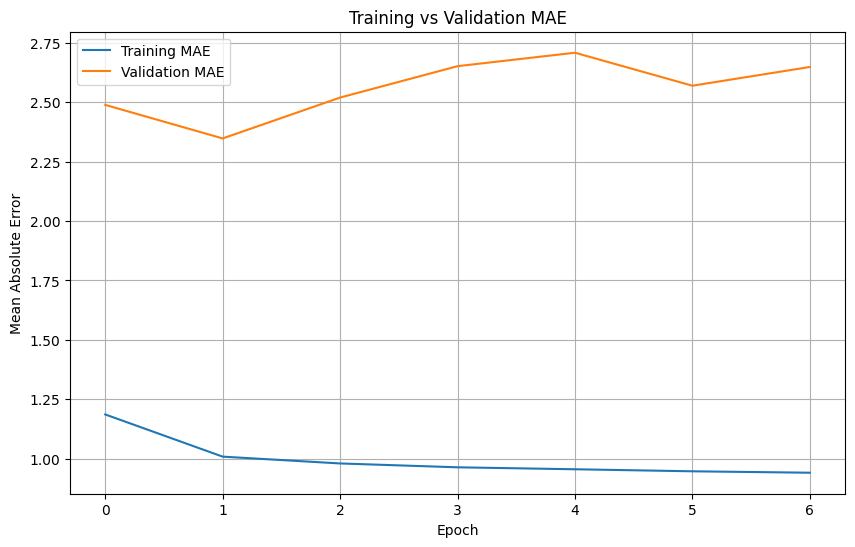

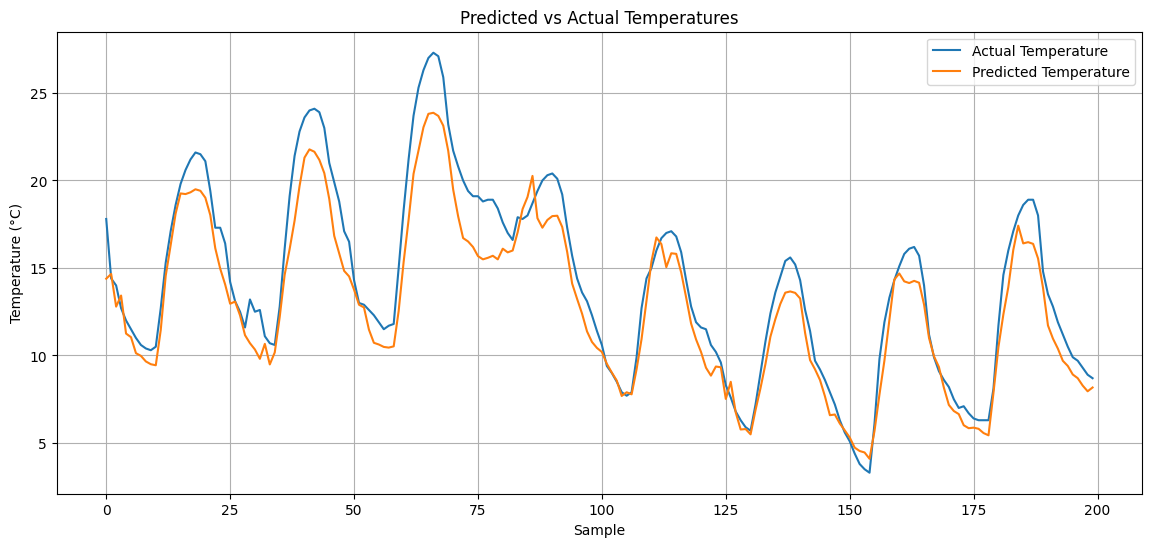

,Actual,Predicted,Error
0,17.8,14.386826,-3.413173
1,14.4,14.659327,0.259328
2,14.0,12.791533,-1.208467
3,12.7,13.424898,0.724898
4,12.0,11.252445,-0.747555
5,11.5,11.044513,-0.455487
6,11.0,10.130589,-0.869411
7,10.6,9.976892,-0.623108
8,10.4,9.659064,-0.740935
9,10.3,9.500292,-0.799708


In [6]:
print(f"Test Loss : {results['loss']:.4f}")
print(f"Test MAE  : {results['mae']:.4f}")
print(f"Test RMSE : {results['rmse']:.4f}")
print(f"Epochs trained: {results['epochs_trained']}")

figure_dir = results["experiment_dir"] / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

plot_loss_curve(results["history"], figure_dir, show=True)
plot_mae_curve(results["history"], figure_dir, show=True)
plot_prediction_curve(results["y_test"], results["predictions"], figure_dir, show=True)

pd.read_csv(results["experiment_dir"] / "predictions.csv").head(10)

## Comparison to the baseline Transformer

Reuses `src/models/common/compare.py`'s `compare()`, now generalized to accept an explicit list of model names so it can look inside this experiment's namespaced results directory alongside the baseline.

In [7]:
compare(["Transformer", f"Transformer/{EXPERIMENT_NAME}"])

------------------------------------------------------------
Model Comparison
------------------------------------------------------------
                                model          experiment      loss      mae     rmse  epochs_trained
                          Transformer 2026-07-17_19-36-12 18.897480 3.534157 4.347123              12
Transformer/exp01_temperature_feature 2026-07-25_16-57-47  7.110312 2.253057 2.666517               7
------------------------------------------------------------
Saved to: /content/repo/models/comparison/comparison.csv
Saved chart to: /content/repo/models/comparison/comparison_chart.png


## Save results

**If running on Colab**, run the cell below to zip this experiment's output folder together with this executed notebook (so the professor can see the real run, including these plots and outputs) and download it as one file. Unzip it directly into your local repo checkout, review with `git status`/`git diff`, then commit and push from your own machine.

**If running locally**, your results are already sitting in the repo at `results["experiment_dir"]` -- nothing more to do.

In [8]:
try:
    import google.colab
    from google.colab import files

    zip_name = f"{EXPERIMENT_NAME}_results.zip"
    notebook_path = f"src/models/transformer/experiments/{EXPERIMENT_NAME}/experiment.ipynb"
    results_glob = f"models/Transformer/{EXPERIMENT_NAME}"

    run(f"zip -r {zip_name} {results_glob} {notebook_path}")
    files.download(zip_name)
except ImportError:
    print("Not running on Colab -- results are already in your local repo checkout.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>